In [44]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [29]:
mu=0.04
L=2.0

In [ ]:
def f1(Q, r, s):
    A          = np.pi * r**2
    K=       1.0/(1-s)**4 - 1.0
    poiseuille = 8.0 * mu * L * Q / (np.pi * r**4) 
    stenosis=  K * Q**2 / (2 * A**2)
    return poiseuille + stenosis

def f2(Q, r, s):
    return 8 * mu * L * Q / (np.pi * r**4)

def f3(Q, r, s):
    Q_bar = 1.0
    r_bar = 0.15
  
    f_bar = 8*mu*L*Q_bar / (np.pi * r_bar**4)
   
    dfdQ  = 8*mu*L / (np.pi * r_bar**4)

    dfdr  = -4 * 8*mu*L*Q_bar / (np.pi * r_bar**5)
   
    return f_bar + dfdQ*(Q - Q_bar) + dfdr*(r - r_bar)


In [40]:
def draw_samples(n, s_max=0.5):
    np.random.seed(42)
    Q = np.random.normal(1.0,  0.2,  n)
    r = np.random.normal(0.15, 0.02, n)
    s = np.random.uniform(0.1, s_max, n)
    return Q, r, s

In [41]:
def estimate_statistics(n_pilot=500, s_max=0.5):
    Q, r, s   = draw_samples(n_pilot, s_max)
    y1        = f1(Q, r, s)
    y2        = f2(Q, r, s)
    y3        = f3(Q, r, s)
    sigma1_sq = np.var(y1, ddof=1)
    rho12     = np.corrcoef(y1, y2)[0, 1]
    rho13     = np.corrcoef(y1, y3)[0, 1]
    return sigma1_sq, rho12, rho13

In [42]:
def compute_gamma(w_sub, rho_sub):
    rho_aug = np.append(rho_sub, 0)
    terms   = np.sqrt(w_sub/w_sub[0] *
                     (rho_aug[:-1]**2 - rho_aug[1:]**2))
    return terms.sum()**2
w = np.array([1.0, 0.1, 0.001])

In [48]:
s_max     = 0.2
sigma1_sq, rho12, rho13 = estimate_statistics(500, s_max)
rho       = np.array([1.0, rho12, rho13])


print(f'sigma1_sq = {sigma1_sq:.6f}')
print(f'rho12     = {rho12:.6f}')
print(f'rho13     = {rho13:.6f}')
print()
print(f'gamma (2 models): {compute_gamma(w[:2], rho[:2]):.2e}')
print(f'gamma (3 models): {compute_gamma(w,     rho):.2e}')

sigma1_sq = 167609.346623
rho12     = 0.992920
rho13     = 0.882797

gamma (2 models): 1.87e-01
gamma (3 models): 8.43e-02


In [49]:
def mse_mc(p,sigma1_sq,w1):
    return sigma1_sq * w1/p
def mse_mfmc(p, w_sub, rho_sub, sigma1_sq):
    """
    MFMC: MSE from Corollary 3.5 eq.(3.19)
    MSE = sigma1^2 / p * (sum sqrt(wi*(rho_i^2-rho_{i+1}^2)))^2
    """
    rho_aug = np.append(rho_sub, 0)
    # r_i* from eq.(3.14)
    r_star = np.sqrt(
        w_sub[0] * (rho_aug[:-1]**2 - rho_aug[1:]**2)
        / (w_sub * (1 - rho_sub[1]**2))
    )
    m1_star = p / (w_sub @ r_star)
    # MSE from eq.(3.19)
    return sigma1_sq * (1 - rho_sub[1]**2) * p \
           / (m1_star**2 * w_sub[0])

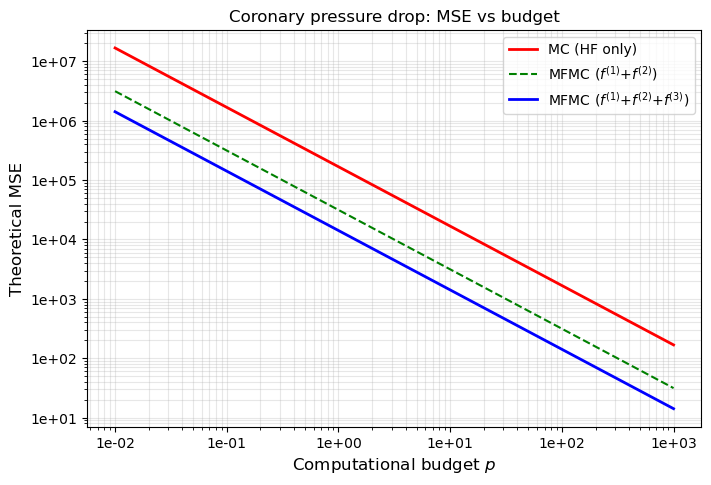

gamma_2 = 1.87e-01
gamma_3 = 8.43e-02
speedup (2 models) = 5.3x
speedup (3 models) = 11.9x


In [ ]:


s_max     = 0.2
sigma1_sq, rho12, rho13 = estimate_statistics(500, s_max)
rho       = np.array([1.0, rho12, rho13])

budgets  = np.logspace(-2, 3, 200)


mse_hf   = np.array([mse_mc(p, sigma1_sq, w[0])
                     for p in budgets])
mse_2mdl = np.array([mse_mfmc(p, w[:2], rho[:2], sigma1_sq)
                     for p in budgets])
mse_3mdl = np.array([mse_mfmc(p, w,     rho,     sigma1_sq)
                     for p in budgets])


fig, ax = plt.subplots(figsize=(7, 5))

ax.loglog(budgets, mse_hf,   'r-',  lw=2,
          label='MC (HF only)')
ax.loglog(budgets, mse_2mdl, 'g--', lw=1.5,
          label=r'MFMC ($f^{(1)}$+$f^{(2)}$)')
ax.loglog(budgets, mse_3mdl, 'b-',  lw=2,
          label=r'MFMC ($f^{(1)}$+$f^{(2)}$+$f^{(3)}$)')

ax.set_xlabel('Computational budget $p$', fontsize=12)
ax.set_ylabel('Theoretical MSE',          fontsize=12)
ax.set_title('Coronary pressure drop: MSE vs budget',
             fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x:.0e}'))
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x:.0e}'))
plt.show()


print(f'gamma_2 = {compute_gamma(w[:2], rho[:2]):.2e}')
print(f'gamma_3 = {compute_gamma(w,     rho):.2e}')
print(f'speedup (2 models) = {1/compute_gamma(w[:2], rho[:2]):.1f}x')
print(f'speedup (3 models) = {1/compute_gamma(w,     rho):.1f}x')